# PolypMix Augmentation for Polyp Segmentation

This notebook integrates **PolypMix augmentation** into the training pipeline.

**Key Features:**
- PolypMix: Polyp-aware data augmentation that mixes images based on polyp probability
- Training on original + augmented data
- Early stopping based on Dice score
- Compatible with Kaggle environment

In [77]:
# Block 1: Install Dependencies & Import Libraries

!pip install -q transformers

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import PIL.Image
import cv2
import glob
import time

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

# Torchvision Imports
import torchvision.transforms as T
from torchvision.transforms.functional import to_pil_image, to_tensor, resize

# Other Imports
from sklearn.model_selection import train_test_split
from transformers import SwinModel

# Setup Seed for Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.8.0+cu126
CUDA available: True


In [78]:
# Block 2: PolypMix Augmentation Module (Self-contained)

class SimplePolypMixAugmentor:
    """
    Mask-based PolypMix augmentation.
    
    Uses ground truth masks to compute mixing weights. The key idea is to
    mix two images by sampling MORE on polyp-like pixels and LESS on
    background-like pixels.
    
    Reference:
        Jia et al. "PolypMixNet: Enhancing Semi-Supervised Polyp Segmentation
        with Polyp-Aware Augmentation", Computers in Biology and Medicine, 2024
    """
    
    def __init__(self, threshold=0.7):
        self.threshold = threshold
        
    def mix_pair(self, image0, mask0, image1, mask1):
        """
        Mix two image-mask pairs using polyp-aware weighting.
        
        Args:
            image0: First image tensor [C, H, W]
            mask0: First mask tensor [1, H, W] or [H, W]
            image1: Second image tensor [C, H, W]
            mask1: Second mask tensor [1, H, W] or [H, W]
            
        Returns:
            mixed_image: Mixed image tensor
            mixed_mask: Mixed mask (pseudo-label)
        """
        # Ensure masks have channel dimension
        if mask0.dim() == 2:
            mask0 = mask0.unsqueeze(0)
        if mask1.dim() == 2:
            mask1 = mask1.unsqueeze(0)
        
        # Normalize masks to [0, 1]
        mask0 = mask0.float()
        mask1 = mask1.float()
        if mask0.max() > 1:
            mask0 = mask0 / 255.0
        if mask1.max() > 1:
            mask1 = mask1 / 255.0
        
        # Compute mix factor: sample more on polyp-like pixels
        eps = 1e-7
        mix_factor = torch.div(mask1, mask0 + mask1 + eps)
        
        # Mix images
        mixed_image = torch.add(
            torch.mul(image0, 1.0 - mix_factor),
            torch.mul(image1, mix_factor),
        )
        
        # Mix masks
        mixed_mask = torch.add(
            torch.mul(mask0, 1.0 - mix_factor),
            torch.mul(mask1, mix_factor),
        )
        
        # Create pseudo-label with threshold filtering
        domain_mask0 = torch.mul(mask0 > mask1, mask0 > self.threshold)
        domain_mask1 = torch.mul(mask1 > mask0, mask1 > self.threshold)
        
        pseudo_mask = torch.add(
            torch.mul(mask0, domain_mask0.float()) + torch.mul(mask1, domain_mask1.float()),
            torch.mul(mixed_mask, torch.logical_not(torch.logical_or(domain_mask0, domain_mask1)).float()),
        )
        
        return mixed_image, pseudo_mask
    
    def __call__(self, image0, mask0, image1, mask1):
        return self.mix_pair(image0, mask0, image1, mask1)


class PolypMixDataset(Dataset):
    """
    Dataset that returns both original and PolypMix augmented samples.
    """
    
    def __init__(self, base_dataset, augment_ratio=1.0, threshold=0.7):
        """
        Args:
            base_dataset: Base dataset that returns (image, mask, filename)
            augment_ratio: Ratio of augmented samples (1.0 = doubles the dataset)
            threshold: Confidence threshold for pseudo-labels
        """
        self.base_dataset = base_dataset
        self.augment_ratio = augment_ratio
        self.threshold = threshold
        
        self.base_len = len(base_dataset)
        self.augment_len = int(self.base_len * augment_ratio)
        
        self.augmentor = SimplePolypMixAugmentor(threshold=threshold)
        self._generate_pairs()
        
    def _generate_pairs(self):
        """Generate random pairs for augmentation."""
        self.pairs = []
        indices = list(range(self.base_len))
        for _ in range(self.augment_len):
            idx0, idx1 = random.sample(indices, 2)
            self.pairs.append((idx0, idx1))
            
    def __len__(self):
        return self.base_len + self.augment_len
    
    def __getitem__(self, index):
        if index < self.base_len:
            # Return original sample
            image, mask, filename = self.base_dataset[index]
            return image, mask, filename
        else:
            # Return augmented sample
            aug_index = index - self.base_len
            idx0, idx1 = self.pairs[aug_index]
            
            image0, mask0, fn0 = self.base_dataset[idx0]
            image1, mask1, fn1 = self.base_dataset[idx1]
            
            mixed_image, mixed_mask = self.augmentor(image0, mask0, image1, mask1)
            
            return mixed_image, mixed_mask, f'aug_{idx0}_{idx1}'
    
    def reshuffle_pairs(self):
        """Reshuffle augmentation pairs (call at start of each epoch)."""
        self._generate_pairs()


print("PolypMix augmentation module loaded successfully!")

PolypMix augmentation module loaded successfully!


In [79]:
# Block 3: Load Dataset (Kaggle)

# For Kaggle - use the input data path
# Update this path to match your Kaggle dataset location
DATA_ROOT = "/kaggle/input/dataset1/CVC-ClinicDB-612"  # Kaggle path
# DATA_ROOT = "/content/CVC-ClinicDB-612"  # Colab path

# Check if running in Kaggle or Colab
if os.path.exists("/kaggle/input"):
    print("Running in Kaggle environment")
    OUTPUT_DIR = "/kaggle/working"
elif os.path.exists("/content"):
    print("Running in Colab environment")
    OUTPUT_DIR = "/content/output"
    DATA_ROOT = "/content/CVC-ClinicDB-612"
else:
    print("Running locally")
    OUTPUT_DIR = "./output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

IMAGE_DIR = os.path.join(DATA_ROOT, "images")
MASK_DIR = os.path.join(DATA_ROOT, "Ground Truth")

print(f"Data root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Running in Kaggle environment
Data root: /kaggle/input/dataset1/CVC-ClinicDB-612
Output directory: /kaggle/working


In [80]:
# Block 4: Configuration

# Training parameters
TRAINING_SIZE = 75           # Options: 25, 50, 75, 100 for SSL
NUM_EPOCHS = 50              # Max epochs (may stop early)
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
IMAGE_SIZE = 224

# PolypMix parameters
USE_POLYPMIX = True          # Enable PolypMix augmentation
POLYPMIX_RATIO = 2.0         # Augmentation ratio 
POLYPMIX_THRESHOLD = 0.7     # Confidence threshold for mixing

# Early stopping parameters
EARLY_STOPPING_PATIENCE = 10  # Stop if no improvement for N epochs

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"--- Experiment Configuration ---")
print(f"Training Size: {TRAINING_SIZE}")
print(f"Max Epochs: {NUM_EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Device: {DEVICE}")
print(f"Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")
print(f"Model Selection Metric: Dice Score")
print(f"PolypMix Enabled: {USE_POLYPMIX}")
if USE_POLYPMIX:
    print(f"  - Augmentation Ratio: {POLYPMIX_RATIO}")
    print(f"  - Threshold: {POLYPMIX_THRESHOLD}")
print("-" * 35)

--- Experiment Configuration ---
Training Size: 75
Max Epochs: 50
Batch Size: 8
Device: cuda
Early Stopping Patience: 10
Model Selection Metric: Dice Score
PolypMix Enabled: True
  - Augmentation Ratio: 2.0
  - Threshold: 0.7
-----------------------------------


In [81]:
# Block 5: Model Architecture (Swin-UNet)

class SwinUNet(nn.Module):
    def __init__(self, num_classes=1):
        super(SwinUNet, self).__init__()
        # Encoder: Pre-trained Swin Transformer
        self.swin = SwinModel.from_pretrained(
            "microsoft/swin-base-patch4-window7-224",
            output_hidden_states=True,
        )

        # Freeze some early layers
        for name, param in self.swin.named_parameters():
            if "layers.0" in name or "layers.1" in name or "embed" in name:
                 param.requires_grad = False

        # Decoder
        self.decoder4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv4 = nn.Sequential(nn.Conv2d(1024, 512, 3, padding=1), nn.ReLU())

        self.decoder3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = nn.Sequential(nn.Conv2d(512, 256, 3, padding=1), nn.ReLU())

        self.decoder2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), nn.ReLU())

        self.final_upsample = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)
        self.final_conv = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, kernel_size=1)
        )

    def forward(self, x):
        hidden_states = self.swin(x).hidden_states

        # Reshape hidden states
        B, L1, C1 = hidden_states[0].shape
        H1 = W1 = int(L1**0.5)
        s1 = hidden_states[0].reshape(B, H1, W1, C1).permute(0, 3, 1, 2)

        B, L2, C2 = hidden_states[1].shape
        H2 = W2 = int(L2**0.5)
        s2 = hidden_states[1].reshape(B, H2, W2, C2).permute(0, 3, 1, 2)

        B, L3, C3 = hidden_states[2].shape
        H3 = W3 = int(L3**0.5)
        s3 = hidden_states[2].reshape(B, H3, W3, C3).permute(0, 3, 1, 2)

        B, L4, C4 = hidden_states[3].shape
        H4 = W4 = int(L4**0.5)
        s4 = hidden_states[3].reshape(B, H4, W4, C4).permute(0, 3, 1, 2)

        # Decoder with skip connections
        d4 = self.decoder4(s4)
        d4 = torch.cat([d4, s3], dim=1)
        d4 = self.conv4(d4)

        d3 = self.decoder3(d4)
        d3 = torch.cat([d3, s2], dim=1)
        d3 = self.conv3(d3)

        d2 = self.decoder2(d3)
        d2 = torch.cat([d2, s1], dim=1)
        d2 = self.conv2(d2)

        out = self.final_upsample(d2)
        out = self.final_conv(out)

        return out

print("SwinUNet model defined.")

SwinUNet model defined.


In [82]:
# Block 6: Loss Functions and Metrics

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        intersection = (probs_flat * targets_flat).sum()
        dice = (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        return 1 - dice

def combined_loss(logits, targets):
    bce = nn.BCEWithLogitsLoss()
    dice = DiceLoss()
    return bce(logits, targets) + dice(logits, targets)

def calculate_metrics(logits, targets, threshold=0.5, epsilon=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    preds_flat = preds.view(-1)
    targets_flat = targets.view(-1)
    intersection = (preds_flat * targets_flat).sum()
    dice_score = (2. * intersection) / (preds_flat.sum() + targets_flat.sum() + epsilon)
    union = preds_flat.sum() + targets_flat.sum() - intersection
    iou_score = intersection / (union + epsilon)
    return iou_score.item(), dice_score.item()

print("Loss functions and metrics defined.")

Loss functions and metrics defined.


In [83]:
# Block 7: Dataset Class

class PolypDataset(Dataset):
    def __init__(self, image_filenames, image_dir, mask_dir):
        self.image_filenames = image_filenames
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.image_transform = T.Compose([
            T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.mask_transform = T.Compose([
            T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        filename = self.image_filenames[idx]
        img_path = os.path.join(self.image_dir, filename)
        mask_path = os.path.join(self.mask_dir, filename)
        
        image = PIL.Image.open(img_path).convert("RGB")
        mask = PIL.Image.open(mask_path).convert("L")

        image = self.image_transform(image)
        mask = self.mask_transform(mask)
        mask = (mask > 0.5).float()

        return image, mask, filename

print("Dataset class defined.")

Dataset class defined.


In [84]:
# Block 8: Data Loading with PolypMix

# Get all filenames
all_filenames = sorted(os.listdir(IMAGE_DIR))
print(f"Total images found: {len(all_filenames)}")

# Split into train and validation
train_pool_files, val_pool_files = train_test_split(
    all_filenames,
    test_size=0.15,
    random_state=SEED
)

print(f"Training pool: {len(train_pool_files)} images")
print(f"Validation pool: {len(val_pool_files)} images")

# Select labeled samples for training
labeled_pool_files = train_pool_files[:TRAINING_SIZE]
print(f"Using {len(labeled_pool_files)} labeled samples for training")

# Create base dataset
train_dataset_base = PolypDataset(
    image_filenames=labeled_pool_files,
    image_dir=IMAGE_DIR,
    mask_dir=MASK_DIR
)

# Apply PolypMix augmentation if enabled
if USE_POLYPMIX:
    train_dataset = PolypMixDataset(
        base_dataset=train_dataset_base,
        augment_ratio=POLYPMIX_RATIO,
        threshold=POLYPMIX_THRESHOLD
    )
    print(f"\nPolypMix augmentation enabled!")
    print(f"  Original samples: {len(train_dataset_base)}")
    print(f"  Augmented samples: {len(train_dataset) - len(train_dataset_base)}")
    print(f"  Total training samples: {len(train_dataset)}")
else:
    train_dataset = train_dataset_base
    print(f"Training with {len(train_dataset)} samples (no augmentation)")

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_dataset = PolypDataset(
    image_filenames=val_pool_files,
    image_dir=IMAGE_DIR,
    mask_dir=MASK_DIR
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"\nData loaders created successfully!")

Total images found: 612
Training pool: 520 images
Validation pool: 92 images
Using 75 labeled samples for training

PolypMix augmentation enabled!
  Original samples: 75
  Augmented samples: 150
  Total training samples: 225

Data loaders created successfully!


Visualizing PolypMix augmentation samples...


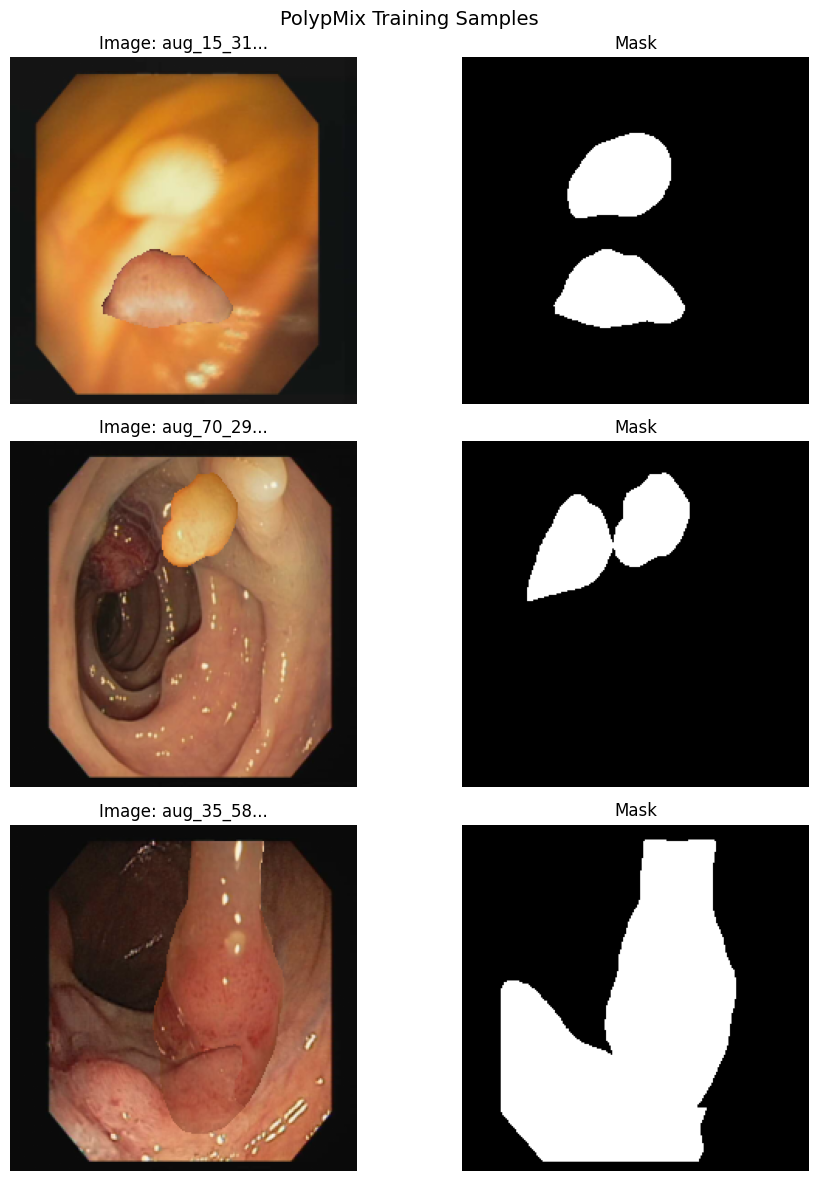

Saved to /kaggle/working/polypmix_samples.png


In [85]:
# Block 9: Visualize PolypMix Augmentation

if USE_POLYPMIX:
    print("Visualizing PolypMix augmentation samples...")
    
    # Get a batch
    images, masks, filenames = next(iter(train_loader))
    
    # Show first 3 samples
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for i in range(min(3, len(images))):
        # De-normalize image
        img = (images[i].cpu() * std) + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        mask = masks[i].cpu().squeeze().numpy()
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Image: {filenames[i][:20]}...")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis('off')
    
    plt.suptitle("PolypMix Training Samples", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "polypmix_samples.png"))
    plt.show()
    print(f"Saved to {os.path.join(OUTPUT_DIR, 'polypmix_samples.png')}")

In [86]:
# Block 10: Initialize Model and Optimizer

model = SwinUNet(num_classes=1).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = combined_loss

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model initialized on {DEVICE}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model initialized on cuda
Total parameters: 95,764,537
Trainable parameters: 93,119,457


In [87]:
# Block 11: Training and Validation Functions

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_iou = 0
    total_dice = 0
    
    for images, masks, _ in tqdm(loader, desc="Training"):
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        iou, dice = calculate_metrics(outputs, masks)
        total_iou += iou
        total_dice += dice
    
    n = len(loader)
    return total_loss / n, total_iou / n, total_dice / n

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_iou = 0
    total_dice = 0
    
    with torch.no_grad():
        for images, masks, _ in tqdm(loader, desc="Validation"):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            total_loss += loss.item()
            iou, dice = calculate_metrics(outputs, masks)
            total_iou += iou
            total_dice += dice
    
    n = len(loader)
    return total_loss / n, total_iou / n, total_dice / n

print("Training and validation functions defined.")

Training and validation functions defined.


In [88]:
RESULTS_TXT = os.path.join(
    OUTPUT_DIR, f"results_polypmix_ratio_{POLYPMIX_RATIO}_ts_{TRAINING_SIZE}.txt"
)


with open(RESULTS_TXT, "w") as f:
    f.write("PolypMix Experiment Results\n")
    f.write("=" * 40 + "\n")
    f.write(f"Batch Size: {BATCH_SIZE}\n")
    f.write(f"PolypMix Ratio: {POLYPMIX_RATIO}\n")
    f.write(f"Threshold: {POLYPMIX_THRESHOLD}\n")
    f.write(f"Training Size: {TRAINING_SIZE}\n")
    f.write(f"Learning Rate: {LEARNING_RATE}\n")
    f.write(f"Image Size: {IMAGE_SIZE}\n")
    f.write("=" * 40 + "\n\n")


In [ ]:
# Block 12: Training Loop with Early Stopping (based on Dice Score)

print("="*60)
print(f"Starting Training with PolypMix Augmentation")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Model selection based on: Dice Score")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE} epochs")
print("="*60)

train_losses = []
val_losses = []
train_dices = []
val_dices = []
train_ious = []
val_ious = []

# Best model tracking (based on Dice score)
best_dice = 0.0
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # Reshuffle augmentation pairs at start of each epoch
    if USE_POLYPMIX and hasattr(train_dataset, 'reshuffle_pairs'):
        train_dataset.reshuffle_pairs()
    
    # Training
    train_loss, train_iou, train_dice = train_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )
    
    # Validation
    val_loss, val_iou, val_dice = validate(
        model, val_loader, criterion, DEVICE
    )
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)
    train_ious.append(train_iou)
    val_ious.append(val_iou)
    
    # Print results
    print(f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | Train IoU: {train_iou:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f}")

    with open(RESULTS_TXT, "a") as f:
      f.write(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f}, "
        f"Train Dice={train_dice:.4f}, "
        f"Train IoU={train_iou:.4f} | "
        f"Val Loss={val_loss:.4f}, "
        f"Val Dice={val_dice:.4f}, "
        f"Val IoU={val_iou:.4f}\n"
      )


    # Save best model based on Dice score
    if val_dice > best_dice:
        best_dice = val_dice
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_dice': best_dice,
            'best_iou': val_iou,
        }, os.path.join(OUTPUT_DIR, 'best_model.pth'))
        print(f"  -> New best model saved! (Dice: {best_dice:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping check
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\n[!] Early stopping triggered! No improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        break
        
with open(RESULTS_TXT, "a") as f:
    f.write("\n" + "=" * 40 + "\n")
    f.write("FINAL BEST RESULT\n")
    f.write(f"Best Validation Dice: {best_dice:.4f}\n")
    f.write(f"Best Epoch: {best_epoch}\n")
    f.write(f"Total Epochs Trained: {epoch + 1}\n")


print("\n" + "="*60)
print(f"Training Complete!")
print(f"Best Validation Dice: {best_dice:.4f} (Epoch {best_epoch})")
print(f"Total epochs trained: {epoch + 1}")
print("="*60)

Starting Training with PolypMix Augmentation
Training samples: 225
Validation samples: 92
Model selection based on: Dice Score
Early stopping patience: 10 epochs

Epoch 1/50
----------------------------------------


Training:   0%|          | 0/29 [00:00<?, ?it/s]

In [ ]:
# Block 13: Plot Training Results

# Use actual number of epochs trained (may be less due to early stopping)
actual_epochs = len(train_losses)
epochs = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss plot
axes[0].plot(epochs, train_losses, 'b-o', label='Train Loss')
axes[0].plot(epochs, val_losses, 'r-o', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Dice plot
axes[1].plot(epochs, train_dices, 'b-o', label='Train Dice')
axes[1].plot(epochs, val_dices, 'r-o', label='Val Dice')
axes[1].axhline(y=best_dice, color='g', linestyle='--', label=f'Best: {best_dice:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Training vs Validation Dice')
axes[1].legend()
axes[1].grid(True)

# IoU plot
axes[2].plot(epochs, train_ious, 'b-o', label='Train IoU')
axes[2].plot(epochs, val_ious, 'r-o', label='Val IoU')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('IoU')
axes[2].set_title('Training vs Validation IoU')
axes[2].legend()
axes[2].grid(True)

plt.suptitle(f'PolypMix Training Results (Best Dice: {best_dice:.4f} at Epoch {best_epoch})', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_results.png'), dpi=150)
plt.show()

print(f"Results saved to {OUTPUT_DIR}")

In [ ]:
# Block 14: Sample Predictions

# Load best model
checkpoint = torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from Epoch {checkpoint['epoch']+1}")
print(f"Best Dice: {checkpoint['best_dice']:.4f}")

# Get validation samples
images, masks, filenames = next(iter(val_loader))
images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)
    preds = (torch.sigmoid(outputs) > 0.5).float()

# Visualize
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(min(3, len(images))):
    # De-normalize image
    img = (images[i].cpu() * std) + mean
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    
    gt_mask = masks[i].cpu().squeeze().numpy()
    pred_mask = preds[i].cpu().squeeze().numpy()
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(gt_mask, cmap='gray')
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(pred_mask, cmap='gray')
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis('off')

plt.suptitle('Sample Predictions', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_predictions.png'), dpi=150)
plt.show()

print("Sample predictions saved!")